In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sb

In [2]:
df=pd.read_csv("class_ipl_22-26_dataset.csv")
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,6,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin..."
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,4,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L..."
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,5,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living..."
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,5,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D..."
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,0,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N..."


In [3]:
df.shape

(367, 25)

In [4]:
df["team1_runs"].describe()

count    367.000000
mean     185.070845
std       36.516265
min       25.000000
25%      161.500000
50%      187.000000
75%      209.000000
max      287.000000
Name: team1_runs, dtype: float64

In [7]:
scaler=StandardScaler()
df["z_score"]=scaler.fit_transform(df[["team1_runs"]])
df[["team1_runs","z_score"]].head(20)


,team1_runs,z_score
0,131,-1.482755
1,177,-0.221322
2,205,0.546506
3,158,-0.742349
4,210,0.683618
5,128,-1.565022
6,210,0.683618
7,137,-1.318220
8,171,-0.385857
9,193,0.217437


In [8]:
outliers=df[abs(df["z_score"])>3]
print("number of outliers:",len(outliers))
outliers[["team1_runs","z_score"]]

number of outliers: 3


,team1_runs,z_score
34,68,-3.210369
304,25,-4.389534
331,75,-3.018411


In [10]:
clean_df=df[abs(df["z_score"])<=3]
print("original rows: ",len(df))
print("rows after removing outliers: ",len(clean_df))

original rows:  367
rows after removing outliers:  364


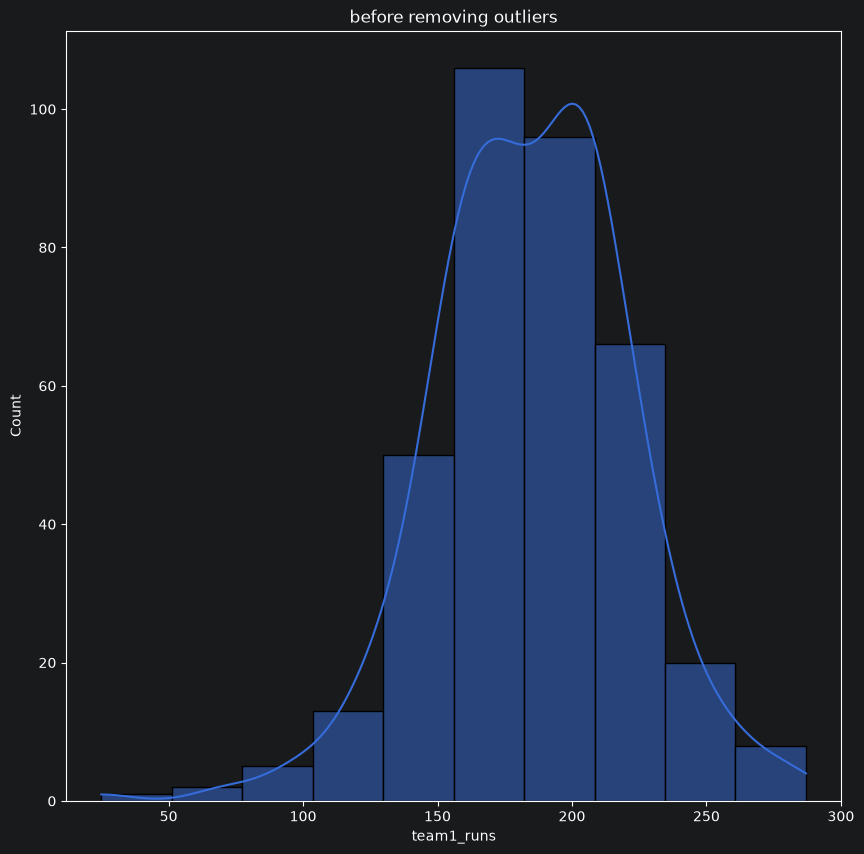

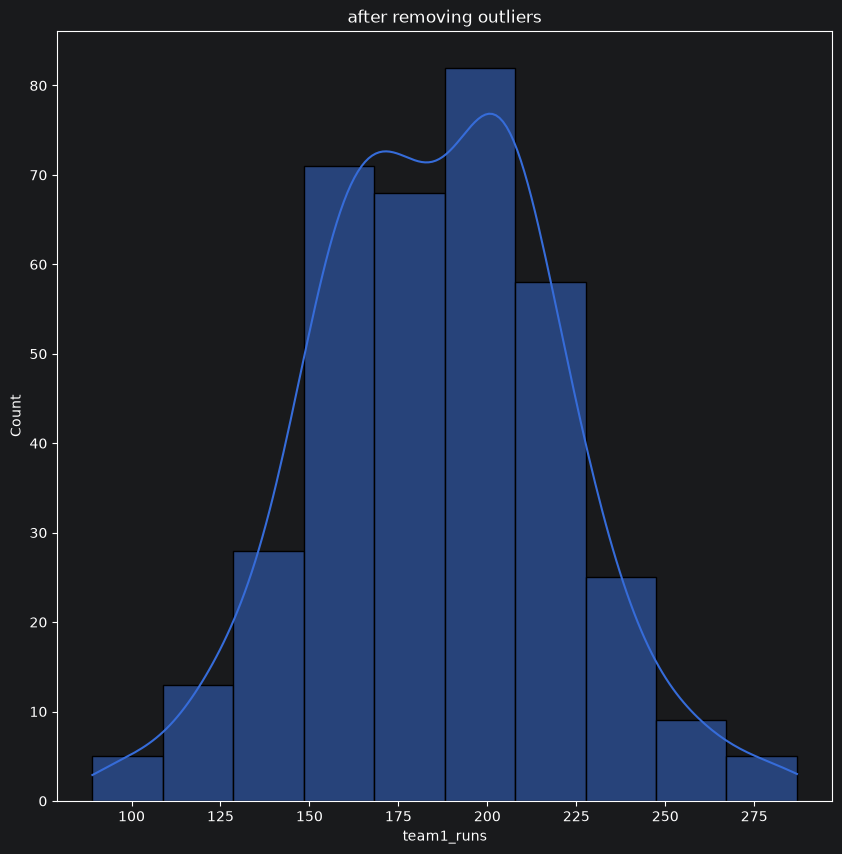

In [11]:
plt.figure(figsize=(10,10))
sb.histplot(df["team1_runs"],kde=True,bins=10)
plt.title("before removing outliers")
plt.xlabel("team1_runs")
plt.show()
plt.figure(figsize=(10,10))
sb.histplot(clean_df["team1_runs"],kde=True,bins=10)
plt.title("after removing outliers")
plt.xlabel("team1_runs")
plt.show()